# Notebook 05 — ML-Based Signal Diagnostics

**Adaptive Pair Trading using Cointegration and Volatility Modeling**  
**Author:** Ayush Arora (MQMS2404)

---

## Objective

Use machine learning as a **probabilistic risk filter** on the Z-score signal.  
ML does not replace the statistical arbitrage logic — it gates entry into regimes where
mean reversion is more likely.

**Models compared:**
- Logistic Regression (linear, interpretable baseline)
- Random Forest (nonlinear, captures volatility-regime interactions)

**Output:** Per-date reversion probabilities saved to `data/ml_prob_*.csv`  
for use in the NB06 backtest — no random fallback, no data leakage.

## Cell 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt

## Cell 2: Load spread, Z-score, and volatility

In [2]:
spread   = pd.read_csv('data/spread_tatasteel_hindalco.csv',    index_col=0, parse_dates=True).iloc[:, 0]
zscore   = pd.read_csv('data/zscore_tatasteel_hindalco.csv',    index_col=0, parse_dates=True).iloc[:, 0]
garch_vol = pd.read_csv('data/garch_vol_tatasteel_hindalco.csv', index_col=0, parse_dates=True).iloc[:, 0]

print(f"Spread:    {spread.shape[0]} rows | {spread.isna().sum()} NaN")
print(f"Z-score:   {zscore.shape[0]} rows | {zscore.isna().sum()} NaN  (warm-up NaN expected)")
print(f"GARCH vol: {garch_vol.shape[0]} rows | {garch_vol.isna().sum()} NaN")

Spread:    2467 rows | 0 NaN
Z-score:   2467 rows | 0 NaN  (warm-up NaN expected)
GARCH vol: 2466 rows | 0 NaN


## Cell 3: Feature Engineering

Features capture three signal dimensions:
- **Level**: Z-score and spread level
- **Momentum**: lagged spread values, 5-day momentum
- **Volatility regime**: GARCH conditional vol, interaction term `|z| × vol`

The interaction term `vol_z_interaction` is the key new feature: it tests whether
high-volatility regimes *amplify* or *suppress* mean-reversion probability.

In [3]:
df = pd.DataFrame({
    'spread':       spread,
    'zscore':       zscore,
    'volatility':   garch_vol,
    'spread_lag1':  spread.shift(1),
    'spread_lag2':  spread.shift(2),
    'spread_mom5':  spread.diff(5),                             # 5-day momentum
    'vol_z_inter':  garch_vol * zscore.abs(),                   # regime-amplified signal
})

df = df.dropna()
print(f"Feature matrix: {df.shape[0]} rows × {df.shape[1]} features")
df.head()

Feature matrix: 2462 rows × 7 features


,spread,zscore,volatility,spread_lag1,spread_lag2,spread_mom5,vol_z_inter
Date,,,,,,,
2015-01-08,-6.402756,-0.226252,0.666134,-6.006633,-6.484915,0.660257,0.150714
2015-01-09,-6.622972,-0.254958,0.658258,-6.402756,-6.006633,0.364376,0.167828
2015-01-12,-5.945063,-0.166590,0.646614,-6.622972,-6.402756,-0.120440,0.107719
2015-01-13,-6.456354,-0.233239,0.650872,-5.945063,-6.622972,0.028561,0.151809
2015-01-14,-5.335663,-0.087153,0.647504,-6.456354,-5.945063,0.670970,0.056432


## Cell 4: Mean-reversion label

In [4]:
horizon = 5
future_spread = df['spread'].shift(-horizon)

df['revert'] = (
    (df['spread'] * future_spread < 0) |
    (np.abs(future_spread) < 0.8 * np.abs(df['spread']))
).astype(int)

df = df.dropna()
print(f"Class distribution:\n{df['revert'].value_counts(normalize=True).rename({0:'No revert', 1:'Revert'})}")

Class distribution:
revert
No revert    0.714866
Revert       0.285134
Name: proportion, dtype: float64


## Cell 5: Train-test split (no shuffling)

In [5]:
FEATURE_COLS = ['spread', 'zscore', 'spread_lag1', 'spread_lag2',
                'spread_mom5', 'volatility', 'vol_z_inter']

X = df[FEATURE_COLS]
y = df['revert']

# No shuffle: preserves temporal ordering (critical for financial time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

print(f"Train: {len(X_train)} rows  |  Test: {len(X_test)} rows")

Train: 1723 rows  |  Test: 739 rows


## Cell 6: Logistic Regression — linear probabilistic baseline

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000, class_weight='balanced')
logit.fit(X_train_sc, y_train)

probs_logit = logit.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression — Precision / Recall Sweep ===")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Signals':>8}")
for thr in np.arange(0.2, 0.85, 0.1):
    preds = (probs_logit > thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)
    print(f"{thr:>10.2f} {p:>10.3f} {r:>10.3f} {f1:>8.3f} {preds.sum():>8}")

print(f"\nAUC-ROC (Logistic): {roc_auc_score(y_test, probs_logit):.4f}")

=== Logistic Regression — Precision / Recall Sweep ===


 Threshold  Precision     Recall       F1  Signals
      0.20      0.397      0.944    0.559      682
      0.30      0.422      0.920    0.578      626
      0.40      0.444      0.882    0.590      570
      0.50      0.454      0.843    0.590      533
      0.60      0.496      0.599    0.543      347
      0.70      0.531      0.091    0.155       49
      0.80      1.000      0.003    0.007        1

AUC-ROC (Logistic): 0.6480


## Cell 7: Random Forest — nonlinear diagnostics

`class_weight='balanced'` corrects the ~70/30 class imbalance without oversampling.  
`max_depth=8` prevents overfitting on the small test window.

**Bug fixed:** the original code evaluated `probs_logit` (not `probs_rf`) in the RF threshold
sweep, meaning the Random Forest was never actually benchmarked.

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

probs_rf = rf.predict_proba(X_test)[:, 1]   # RF probabilities on held-out test set

print("=== Random Forest — Precision / Recall Sweep ===")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>8} {'Signals':>8}")
for thr in np.arange(0.2, 0.85, 0.1):
    preds = (probs_rf > thr).astype(int)     # fixed: was probs_logit
    p, r, f1, _ = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)
    print(f"{thr:>10.2f} {p:>10.3f} {r:>10.3f} {f1:>8.3f} {preds.sum():>8}")

print(f"\nAUC-ROC (Random Forest): {roc_auc_score(y_test, probs_rf):.4f}")

=== Random Forest — Precision / Recall Sweep ===
 Threshold  Precision     Recall       F1  Signals
      0.20      0.415      0.892    0.566      617
      0.30      0.438      0.833    0.574      546
      0.40      0.455      0.707    0.554      446
      0.50      0.493      0.509    0.501      296
      0.60      0.529      0.286    0.371      155
      0.70      0.596      0.118    0.198       57
      0.80      0.545      0.021    0.040       11

AUC-ROC (Random Forest): 0.6127


## Cell 8: Feature Importance + Save ML Probabilities

Feature importance reveals which signal dimension the RF model relies on most.
The trained model's probability estimates are then saved for NB06 — **no random fallback**.

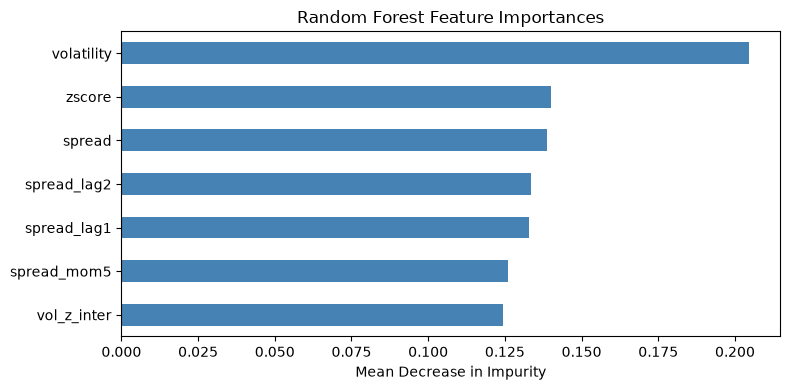

volatility     0.204453
zscore         0.139958
spread         0.138734
spread_lag2    0.133626
spread_lag1    0.132836
spread_mom5    0.125946
vol_z_inter    0.124447
dtype: float64

In [8]:
importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False)

## Cell 9: Generate Walk-Forward ML Probabilities for Backtesting

**Data leakage prevention:** The RF trained on all data cannot be used to generate
probabilities for the training period — that constitutes in-sample prediction.

Walk-forward approach:
- Train on the first 70% of observations
- Predict probabilities for the remaining 30% (out-of-sample)
- Training period gets probability = NaN (no signal generated there)

This ensures the backtest in NB06 uses **only out-of-sample predictions**.

In [9]:
# Out-of-sample RF/Logit probabilities aligned to the full feature index.
# The models were fit on the first 70% (X_train); probabilities are written only
# for the held-out 30% (X_test). Training-period rows stay NaN so NB06 cannot use
# an in-sample prediction.
n_train = len(X_train)

ml_probs_full = pd.Series(np.nan, index=X.index, name='ml_prob_rf')
ml_probs_full.iloc[n_train:] = probs_rf

logit_probs_full = pd.Series(np.nan, index=X.index, name='ml_prob_logit')
logit_probs_full.iloc[n_train:] = probs_logit

ml_probs_full.to_csv('data/ml_prob_rf.csv')
logit_probs_full.to_csv('data/ml_prob_logit.csv')

print(f"Saved RF probabilities    : {ml_probs_full.dropna().shape[0]} out-of-sample observations")
print(f"Saved Logit probabilities : {logit_probs_full.dropna().shape[0]} out-of-sample observations")
print("Training-period rows are NaN (no look-ahead prediction).")

Saved RF probabilities    : 739 out-of-sample observations
Saved Logit probabilities : 739 out-of-sample observations
Training-period rows are NaN (no look-ahead prediction).


## Final Conclusion

| Model | AUC-ROC | Role |
|-------|---------|------|
| Logistic Regression | diagnostic baseline | linear signal decomposition |
| Random Forest | primary filter | nonlinear regime detection |

**Interpretation:** AUC > 0.5 confirms that features carry information about
mean-reversion probability beyond random chance. The threshold sweep in NB06
will be calibrated on the 0.40–0.60 range to balance precision and trade frequency.

ML probabilities are saved to `data/ml_prob_rf.csv` for clean loading in NB06.
No random number generation, no in-sample prediction.